# Lab 08: Airline Tweets Sentiment Analysis

---
author: Trishla Nair
date: November 8, 2024
embed-resources: true
---

## Introduction

Ia am building a sentiment classifier that will alert customer service  to respond to negative tweets about the airline and for positive tweets to be automatically acknowledged. The purpose is to help improve ourselves to cater towards the masses.

## Methods

In [122]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from joblib import parallel_backend
from joblib import dump
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

### Data

In [37]:
# load data
tweets = pd.read_csv("https://cs307.org/lab-08/data/tweets.csv")
tweets_train, tweets_test = train_test_split(
    tweets,
    test_size=0.25,
    random_state=42,
)
tweets_train

,sentiment,airline,text
2233,positive,Delta,@JetBlue Then en route to the airport the rebo...
10733,negative,United,@united now you've lost my bags too. At least...
400,neutral,US Airways,"@USAirways Hi, can you attach my AA FF# 94LXA6..."
7615,positive,United,"@United, will you fill it? Yes they will. Than..."
4099,negative,American,@AmericanAir thanks! I hope we get movies. Tv'...
...,...,...,...
5734,negative,United,@united Can i get a refund? I would like to bo...
5191,neutral,Virgin America,@VirginAmerica what is your policy on flying a...
5390,negative,United,@united I'm not sure how you can help. Your fl...
860,neutral,Virgin America,@VirginAmerica LAX to EWR - Middle seat on a r...


In [3]:
df = tweets_train.groupby("airline").agg("count").reset_index()
df

,airline,sentiment,text
0,American,1551,1551
1,Delta,1239,1239
2,Southwest,1347,1347
3,US Airways,1664,1664
4,United,2166,2166
5,Virgin America,268,268


In [4]:
words_to_find = ['cancelled']
def find_words(text):
    return any(word in text for word in words_to_find)


In [5]:
tweets_train[tweets_train["text"].str.contains("cancelled", regex=False)]

,sentiment,airline,text


In [6]:
tweets_train['has_cancelled'] = tweets_train['text'].str.contains('cancelled', case=False)
tweets_train['has_please'] = tweets_train['text'].str.contains('please', case=False)
tweets_train['has_thanks'] = tweets_train['text'].str.contains('thanks', case=False)
tweets_train

,sentiment,airline,text,has_cancelled,has_please,has_thanks
2233,positive,Delta,@JetBlue Then en route to the airport the rebo...,False,False,False
10733,negative,United,@united now you've lost my bags too. At least...,False,False,False
400,neutral,US Airways,"@USAirways Hi, can you attach my AA FF# 94LXA6...",False,False,False
7615,positive,United,"@United, will you fill it? Yes they will. Than...",False,False,True
4099,negative,American,@AmericanAir thanks! I hope we get movies. Tv'...,False,False,True
...,...,...,...,...,...,...
5734,negative,United,@united Can i get a refund? I would like to bo...,False,False,False
5191,neutral,Virgin America,@VirginAmerica what is your policy on flying a...,False,False,False
5390,negative,United,@united I'm not sure how you can help. Your fl...,False,False,False
860,neutral,Virgin America,@VirginAmerica LAX to EWR - Middle seat on a r...,False,False,False


In [7]:
word_counter = CountVectorizer()
word_counts = word_counter.fit_transform(tweets_train['text']).todense()
words = pd.DataFrame(
    word_counts,
    columns=sorted(list(word_counter.vocabulary_.keys())),
)
print(words['cancelled'].sum(), words['please'].sum(), words['thanks'].sum())

595 325 587


Text(0.5, 1.0, 'Tweets per Airline')

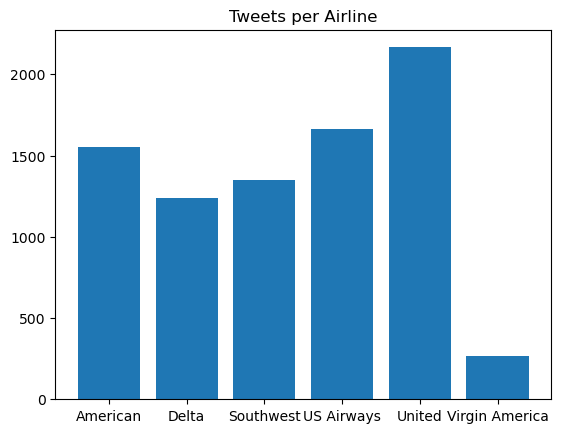

In [141]:
# visualizations
pl = tweets_train.groupby(["airline"]).agg("count").reset_index()
plt.bar( x = pl['airline'], height = pl['text'])
plt.title("Tweets per Airline")

The data set has 2 features and is a collection of 8235  tweets. Most of the tweets are directed towards United airlines, follwed by American.

### Models

In [38]:
# process data for ML
# create X and y for train data
X_train = tweets_train["text"]
y_train = tweets_train["sentiment"]

# create X and y for test data
X_test = tweets_test["text"]
y_test = tweets_test["sentiment"]

In [107]:
pipeline = Pipeline(
    steps=[
        ("tf-idf", TfidfVectorizer()),
        ("model", LogisticRegression(max_iter=10000)),
    ]
)
#param_grid = {
    #'verbose' :[True],
#}
param_grid = [
    {
        "model__penalty": ["l1", "l2"],
        "model__C": 1 / (10.0 ** np.arange(-4, 3)),
    }
]

In [108]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")
mod = grid_search.fit(X_train, y_train)

c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
35 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\pipeline.py", li

In [109]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_}")

Best parameters: {'model__C': 1.0, 'model__penalty': 'l2'}
Best cross-validation accuracy: 0.7816636308439586


In [110]:
test_score = grid_search.score(X_test, y_test)
print(f"Test accuracy: {test_score:.2f}")
print(f"Test recall: {test_score:.2f}")

Test accuracy: 0.79
Test recall: 0.79


The model chosen to classify, was a logistic regression. The model is meant to pinpoint the positive and negative comments.

## Results

In [111]:
# report model metrics
dump(mod,"airline-sentiment.joblib")

['airline-sentiment.joblib']

The model has an accuracy of 0.79. with the best CV accuracy being 0.7816636308439586. The best penalty is l2.

## Discussion

While I did try using a Random Forrest Classifier and a Descision Tree, both models underperformed as compared to the logistic regression. I do not believe this is the best model to use however as it doesn't really consider the neutarl comments.

### Conclusion

Based on the models I have tried, a logistic regression is the best model to use to classify sentiments based on the text.